In [1]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import h5py
import os
print(os.getpid())
%cd ../../

import pylib.mix as mix

from matplotlib import colors


plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

20357
/media/work/docs/codes/QuCF/scripts-py


In [2]:
path_save_ = "./jupyter-notebooks/Carleman/results/"
for i in range(100):
    plt.close()

colors_     = ["blue", "red", "green", "gray", "black"]
linestyles_ = ["-", "--", "--", ":"]

In [23]:
# ---------------------------------------------------------------
# --- Prepare the system ---
# ---------------------------------------------------------------
mix.reload_module(mix)

sel_case_ = 2

# --- 1 attractor ---
if sel_case_ == 0:
    N_nl_orig_ = 1
    F_terms_ = [None] * (N_nl_orig_ + 1)
    a1 = 0.5
    F_ = lambda x:  a1 - x
    F_terms_[1], F_terms_[0] = -1., a1 
    tmax_ = 16.0
    x_centers_ = [-0.95 + 0.05 * ii for ii in range(40)]

# --- 1 attractor and an unstable point ---
if sel_case_ == 1:
    N_nl_orig_ = 2
    F_terms_ = [None] * (N_nl_orig_ + 1)
    a1, b1 = 0.3, 1.02
    F_ = lambda x:  (a1 - x) * (b1 - x)
    F_terms_[2], F_terms_[1], F_terms_[0] = 1., -(a1 + b1), a1*b1 
    tmax_ = 16.0
    # x_centers_ = [-0.95 + 0.05 * ii for ii in range(40)]
    x_centers_ = [-0.90 + 0.20 * ii for ii in range(9)]

# --- 2 attractors and an unstable point ---
if sel_case_ == 2:
    N_nl_orig_ = 3
    F_terms_ = [None] * (N_nl_orig_ + 1)
    
    # a1, b1, c1 = 0.4, -1.1, -1.6   # works
    # a1, b1, c1 = 0.4, -0.2, -1.6   # does not work
    # a1, b1, c1 = 0.4, -0.9, -1.6   # works (attention)
    # a1, b1, c1 = 0.4, -1.2, -1.6   # works (attention)
    # a1, b1, c1 = 0.4, -0.9, -0.96  # oscillations around one stable point
    # a1, b1, c1 = 0.9, -0.2, -0.6   # if unstable point is too close to the zero, does not work
    # a1, b1, c1 = 0.9, 0.6, -0.2   # aims to the point which is closer to the zero
    # a1, b1, c1 = 0.9, 0.2, -0.2   # does not work (oscillations)
    # a1, b1, c1 = 0.8, -1.1, -1.6   # if both stable and unstable points are far away from zero 
    #                                # and even if the unstable points is not in the unit disk, 
    #                                # does not work
    # a1, b1, c1 = 0.4, -1.1, -1.6 
    a1, b1, c1 = 0.4, -0.8, -1.6 

    F_ = lambda x:  (a1 - x) * (b1 - x) * (c1 - x)
    F_terms_[3], F_terms_[2], F_terms_[1], F_terms_[0] = -1., (a1 + b1 + c1), -(a1*b1 + a1*c1 + b1*c1), a1*b1*c1
    tmax_ = 16.0
    x_centers_ = [-0.95 + 0.05 * ii for ii in range(40)]
    # x_centers_ = [-0.90 + 0.20 * ii for ii in range(9)]

# ------------------------------------------------------------------------------
flag_sim_ = True

nt_ = 9

Nt_ = 1 << nt_

t_ = np.linspace(0, tmax_, Nt_)
dt_ = np.diff(t_)[0]

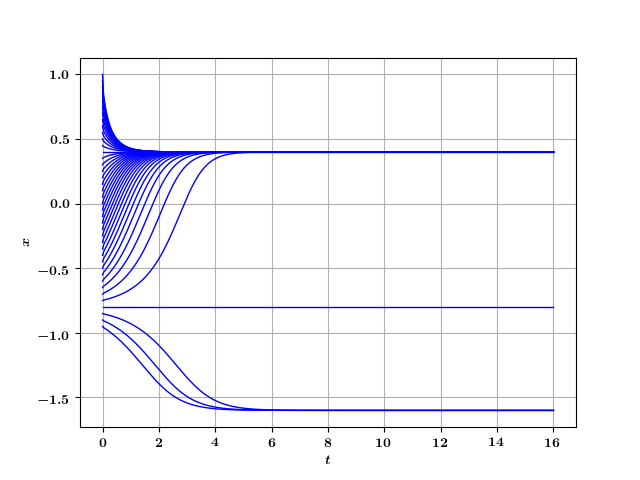

In [24]:
# -----------------------------------------------------------------
# --- Standard method (for reference) ---
# -----------------------------------------------------------------
from scipy.integrate import RK45
mix.reload_module(mix)
def solve_standart(x_center_ref):
    oo = RK45(
        lambda t,x: F_(x), 
        t_[0], 
        [x_center_ref], t_[-1], first_step=dt_, max_step=dt_
    )
    
    sol_ref = np.zeros(Nt_, dtype=float)
    sol_ref[0] = x_center_ref
    Nt_act = 1
    
    oo.step()
    oo.t
    while mix.compare_two_strings(oo.status, "running"):
        oo.step()
        Nt_act += 1
        if Nt_act - 1 == Nt_:
            print(oo.t)
        sol_ref[Nt_act-1] = float(oo.y[0])
    return sol_ref
# --------------------------------------------------------------------------

if flag_sim_:
    sol_refs = []
    plt.close()
    fig = plt.figure()
    ax = fig.add_subplot(111)
    for i_center in range(len(x_centers_)):
        x_center = x_centers_[i_center]
    
        # --- Solve for the particular x_center ---
        sol_one = solve_standart(x_center)
        sol_refs.append(sol_one)
    
        # --- Plotting ---
        ax.plot(
            t_, sol_one, 
            "b", 
            linewidth = 1, linestyle='-', 
        )
        del x_center
    plt.xlabel('$t$')
    plt.ylabel("$x$")
    # plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Simulations are blocked.")

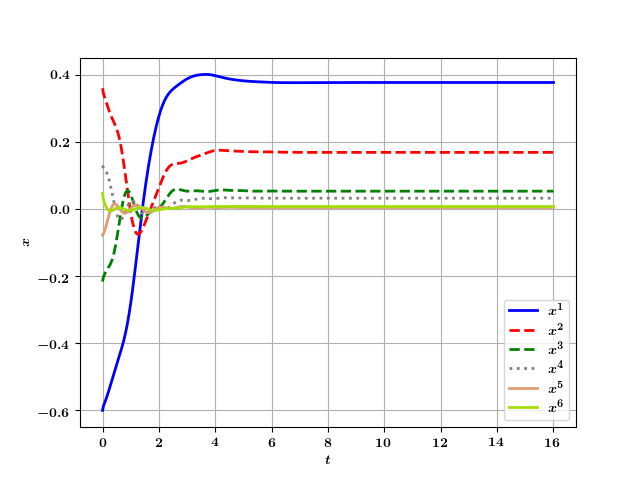

In [25]:
# --------------------------------------------------------------------
# --- Carleman linearization ---
# --------------------------------------------------------------------
from scipy.integrate import RK45
import random
mix.reload_module(mix)
def solve_carleman(x_init, N_nl):
    def f_to_RK(t, x):
        f_eqs = np.dot(A, x) + B
        return f_eqs
    # --------------------------------------------------------------


    # --- Form the system ---
    B = np.zeros(N_nl)
    B[0] = F_terms_[0]

    A       = np.zeros((N_nl, N_nl))
    xs_init = np.zeros(N_nl)
    for ir in range(N_nl):
        xs_init[ir] = x_init**(ir + 1)

        c1 = 1 + ir
        A[ir,ir] = c1 * F_terms_[1]

        # element to the left from the main diagonal
        if ir > 0:
            A[ir, ir-1] = c1 * F_terms_[0]

        # elements to the right from the main diagonal   
        for i_nl in range(N_nl_orig_ - 1):
            if ir < (N_nl - (i_nl + 1)):
                A[ir, ir + 1 + i_nl] = c1 * F_terms_[2 + i_nl]
    del c1


    # --- Runge-Kutta solver ---
    oo = RK45(
        f_to_RK,
        t_[0], 
        xs_init, 
        t_[-1], first_step=dt_, max_step=dt_
    )

    sol_carleman      = np.zeros((Nt_, N_nl))
    sol_carleman[0,:] = xs_init
    Nt_act = 1

    oo.step()
    oo.t
    while mix.compare_two_strings(oo.status, "running"):
        oo.step()
        Nt_act += 1
        if Nt_act - 1 == Nt_:
            print(oo.t)
        sol_carleman[Nt_act-1,:] = oo.y.copy()
    return sol_carleman
# -----------------------------------------------------------------------

N_nl = 6   # should be >= N_nl_orig_
x_init = -0.6
# x_init = -1.6  # when unstable point at -0.90 and a stable at -1.6, Carleman aims to 0.4
# x_init = -1.8  # works for un = -1.2, s = 0.4, -1.6, but aims to 0.4

sol_carleman_ = solve_carleman(x_init, N_nl)


# ---------------------
# --- Plotting ---
if flag_sim_:
    plt.close()
    fig = plt.figure()
    ax = fig.add_subplot(111)

    for ir in range(N_nl):
        color_1 = "#%06x" % random.randint(0, 0xFFFFFF)
        linesty_1 = "-"
        if ir < 4:
            color_1 = colors_[ir]
            linesty_1 = linestyles_[ir]

        line_ord = ""

        ax.plot(
            t_, sol_carleman_[:,ir], 
            color=color_1, linewidth = 2, linestyle=linesty_1, 
            label = "$x^{:d}$".format(ir+1)
        )
    plt.xlabel('$t$')
    plt.ylabel("$x$")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Simulations are blocked.")


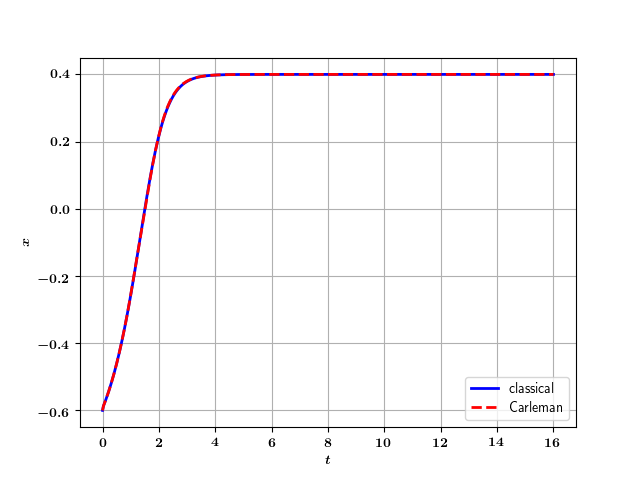

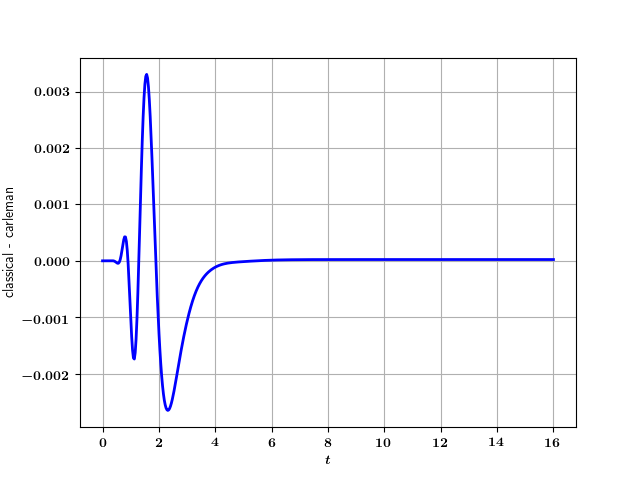

In [27]:
# --------------------------------------------------------------------
# --- Compare trajectories ---
# --------------------------------------------------------------------
def compare_trajectory_cl_and_carleman(x_init, N_nl):
    sol_classical = solve_standart(x_init)
    sol_carleman  = solve_carleman(x_init, N_nl)

    # --- plotting --
    plt.close()
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(
        t_, sol_classical, 
        color="b", linewidth = 2, linestyle='-', label = "classical"
    )
    ax.plot(
        t_, sol_carleman[:,0], 
        color="r", linewidth = 2, linestyle="--", label = "Carleman"
    )
    plt.xlabel('$t$')
    plt.ylabel("$x$")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(
        t_, sol_classical - sol_carleman[:,0], 
        color="b", linewidth = 2, linestyle='-'
    )
    plt.xlabel('$t$')
    plt.ylabel("classical - carleman")
    plt.grid(True)
    plt.show()
    return
# ------------------------------------------------------------------------------------
N_nl = 16
x_init = - 0.6
compare_trajectory_cl_and_carleman(x_init, N_nl)